#Responsible Credit Scoring
##Predictive Risk Modeling & Ethical Fairness Auditing
###Student: Carlos Elizondo
###Student Number: 500890062
### Supervisor: Tamer Abdou
**Toronto Metropolitan University**

## EDA Reports:

In [ ]:

# Generates two HTML reports: YData Profiling + SweetViz TARGET comparison
# Installing libraries
!pip install ydata-profiling -q
!pip install sweetviz -q
!pip install matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 51.2 MB/s eta 0:00:00


In [ ]:
# Imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# Load my master matrix from Drive
df = pd.read_csv('/content/drive/MyDrive/CIND820_Project/master_feature_matrix.csv')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Class balance:\n{df['TARGET'].value_counts(normalize=True).round(3)}")



Mounted at /content/drive
Loaded: 307,511 rows x 66 columns
Class balance:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


In [ ]:
# Fix data types before profiling
# YData and SweetViz can misread types — I need to correct them first so distributions and correlations are not distorted

# Binary flags — should be categorical not numeric
flag_cols = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'TARGET']
for col in flag_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

# CODE_GENDER — categorical
if 'CODE_GENDER' in df.columns:
    df['CODE_GENDER'] = df['CODE_GENDER'].astype(str)

# Restore TARGET as integer for SweetViz comparison (needs numeric)
df['TARGET'] = df['TARGET'].map({'0': 0, '1': 1, '0.0': 0, '1.0': 1}).fillna(df['TARGET'].astype(float))
df['TARGET'] = df['TARGET'].astype(int)

print("Data types corrected.")
print(df.dtypes.value_counts())

Data types corrected.
float64    50
object     10
int64       6
Name: count, dtype: int64


In [ ]:
# Add missingness flag columns
# For high-missingness columns i am adding binary flags before imputation
# These flags ARE themselves informative features (thin-file signal)

high_missing = ['EXT_SOURCE_1', 'EXT_SOURCE_3', 'BUR_MAX_OVERDUE_AMT', 'CC_AVG_UTILIZATION']
for col in high_missing:
    if col in df.columns:
        df[f'FLAG_MISSING_{col}'] = df[col].isnull().astype(int)

print("Missingness flags added:")
for col in high_missing:
    flag = f'FLAG_MISSING_{col}'
    if flag in df.columns:
        print(f"  {flag}: {df[flag].sum():,} flagged as missing")

Missingness flags added:
  FLAG_MISSING_EXT_SOURCE_1: 173,378 flagged as missing
  FLAG_MISSING_EXT_SOURCE_3: 60,965 flagged as missing
  FLAG_MISSING_BUR_MAX_OVERDUE_AMT: 123,625 flagged as missing
  FLAG_MISSING_CC_AVG_UTILIZATION: 221,475 flagged as missing


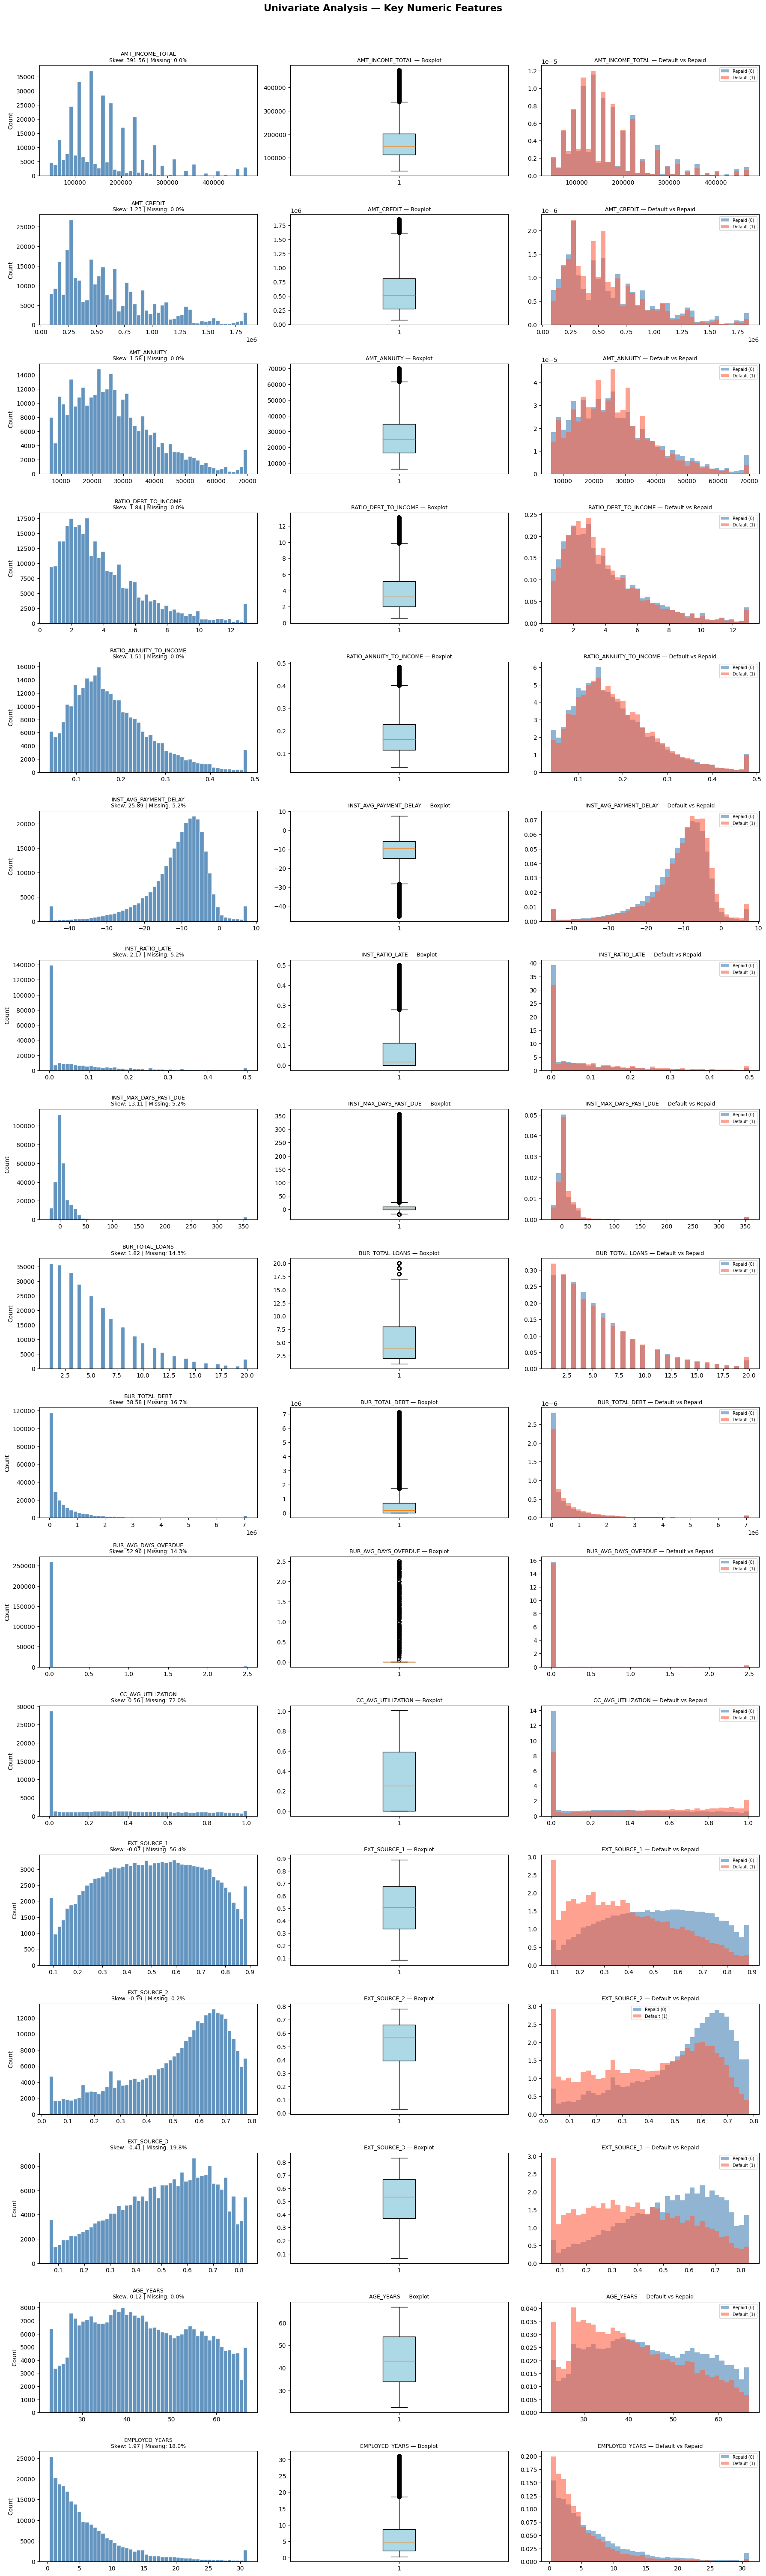

Univariate plots saved.


In [ ]:
# Manual univariate plots
# Prof recommended to have: distributions, skewness, missing ratio, uniformity

numeric_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'RATIO_DEBT_TO_INCOME', 'RATIO_ANNUITY_TO_INCOME',
    'INST_AVG_PAYMENT_DELAY', 'INST_RATIO_LATE', 'INST_MAX_DAYS_PAST_DUE',
    'BUR_TOTAL_LOANS', 'BUR_TOTAL_DEBT', 'BUR_AVG_DAYS_OVERDUE',
    'CC_AVG_UTILIZATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AGE_YEARS', 'EMPLOYED_YEARS'
]
# Filter to only columns that exist
numeric_features = [c for c in numeric_features if c in df.columns]

fig, axes = plt.subplots(len(numeric_features), 3, figsize=(18, len(numeric_features) * 3.5))
fig.suptitle('Univariate Analysis — Key Numeric Features', fontsize=16, fontweight='bold', y=1.01)

for i, col in enumerate(numeric_features):
    series = df[col].dropna()
    skew = series.skew().round(2)
    missing_pct = (df[col].isnull().sum() / len(df) * 100).round(1)

    # Histogram
    axes[i, 0].hist(series.clip(series.quantile(0.01), series.quantile(0.99)),
                    bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i, 0].set_title(f'{col}\nSkew: {skew} | Missing: {missing_pct}%', fontsize=9)
    axes[i, 0].set_ylabel('Count')

    # Boxplot
    axes[i, 1].boxplot(series.clip(series.quantile(0.01), series.quantile(0.99)),
                       vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[i, 1].set_title(f'{col} — Boxplot', fontsize=9)

    # Default vs Non-default distribution overlay
    default_0 = df[df['TARGET'] == 0][col].dropna()
    default_1 = df[df['TARGET'] == 1][col].dropna()
    clip_lo = series.quantile(0.01)
    clip_hi = series.quantile(0.99)
    axes[i, 2].hist(default_0.clip(clip_lo, clip_hi), bins=40,
                    alpha=0.6, color='steelblue', label='Repaid (0)', density=True)
    axes[i, 2].hist(default_1.clip(clip_lo, clip_hi), bins=40,
                    alpha=0.6, color='tomato', label='Default (1)', density=True)
    axes[i, 2].set_title(f'{col} — Default vs Repaid', fontsize=9)
    axes[i, 2].legend(fontsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CIND820_Project/univariate_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Univariate plots saved.")

In [ ]:
# Skewness and missing ratio summary table
print("=== SKEWNESS AND MISSING RATIO SUMMARY ===\n")

summary_rows = []
for col in numeric_features:
    series = df[col].dropna()
    summary_rows.append({
        'Feature': col,
        'Missing %': round(df[col].isnull().sum() / len(df) * 100, 2),
        'Skewness': round(series.skew(), 3),
        'Mean': round(series.mean(), 3),
        'Median': round(series.median(), 3),
        'Std': round(series.std(), 3),
        'Min': round(series.min(), 3),
        'Max': round(series.max(), 3),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Skewness', ascending=False)
print(summary_df.to_string(index=False))

# Save it
summary_df.to_csv('/content/drive/MyDrive/CIND820_Project/feature_summary_stats.csv', index=False)
print("\nSummary table saved.")

=== SKEWNESS AND MISSING RATIO SUMMARY ===

                Feature  Missing %  Skewness       Mean     Median         Std          Min          Max
       AMT_INCOME_TOTAL       0.00   391.560 168797.919 147150.000  237123.146    25650.000 1.170000e+08
   BUR_AVG_DAYS_OVERDUE      14.31    52.964      1.036      0.000      25.825        0.000 2.776000e+03
         BUR_TOTAL_DEBT      16.71    38.582 659059.531 184500.000 1653606.380 -6981558.410 3.344983e+08
 INST_AVG_PAYMENT_DELAY       5.16    25.888    -11.202     -9.542      13.149     -295.000 1.884205e+03
 INST_MAX_DAYS_PAST_DUE       5.16    13.110     16.231      1.000     111.096     -156.000 2.884000e+03
        INST_RATIO_LATE       5.16     2.167      0.076      0.019       0.116        0.000 1.000000e+00
         EMPLOYED_YEARS      18.01     1.968      6.532      4.515       6.406        0.000 4.907400e+01
   RATIO_DEBT_TO_INCOME       0.00     1.836      3.958      3.265       2.690        0.005 8.473700e+01
        BUR

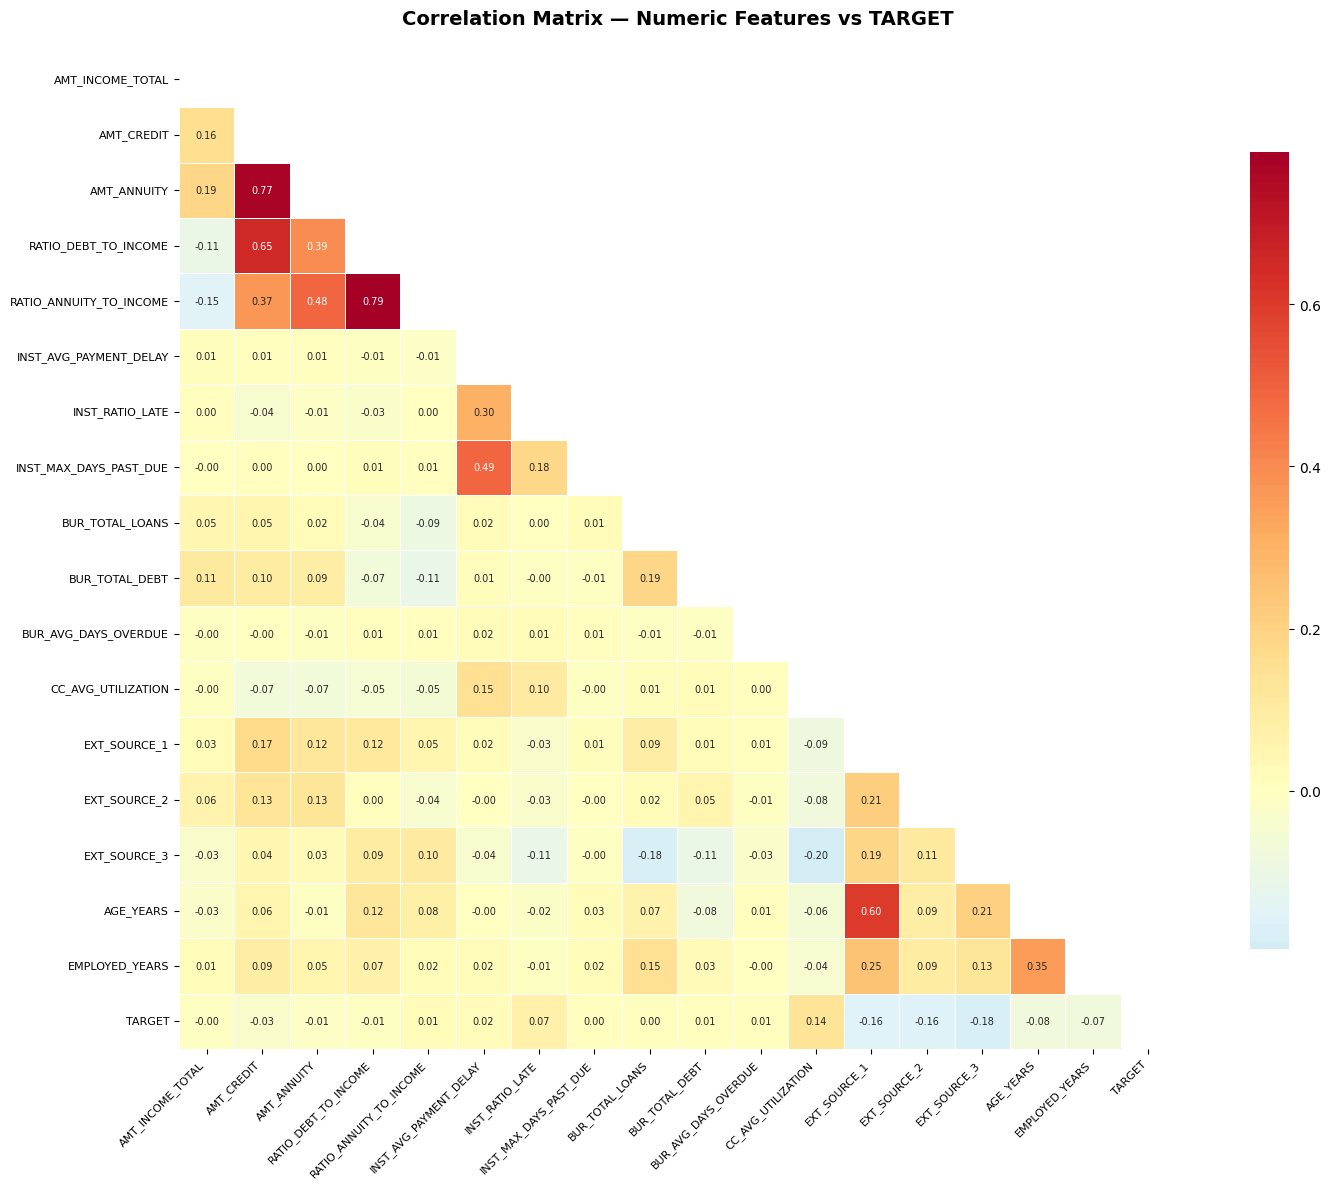

Correlation heatmap saved.


In [ ]:
# Correlation heatmap
# Shows multivariate relationships between numeric features

corr_features = [c for c in numeric_features if df[c].isnull().mean() < 0.75]
corr_matrix = df[corr_features + ['TARGET']].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix — Numeric Features vs TARGET', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CIND820_Project/correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved.")

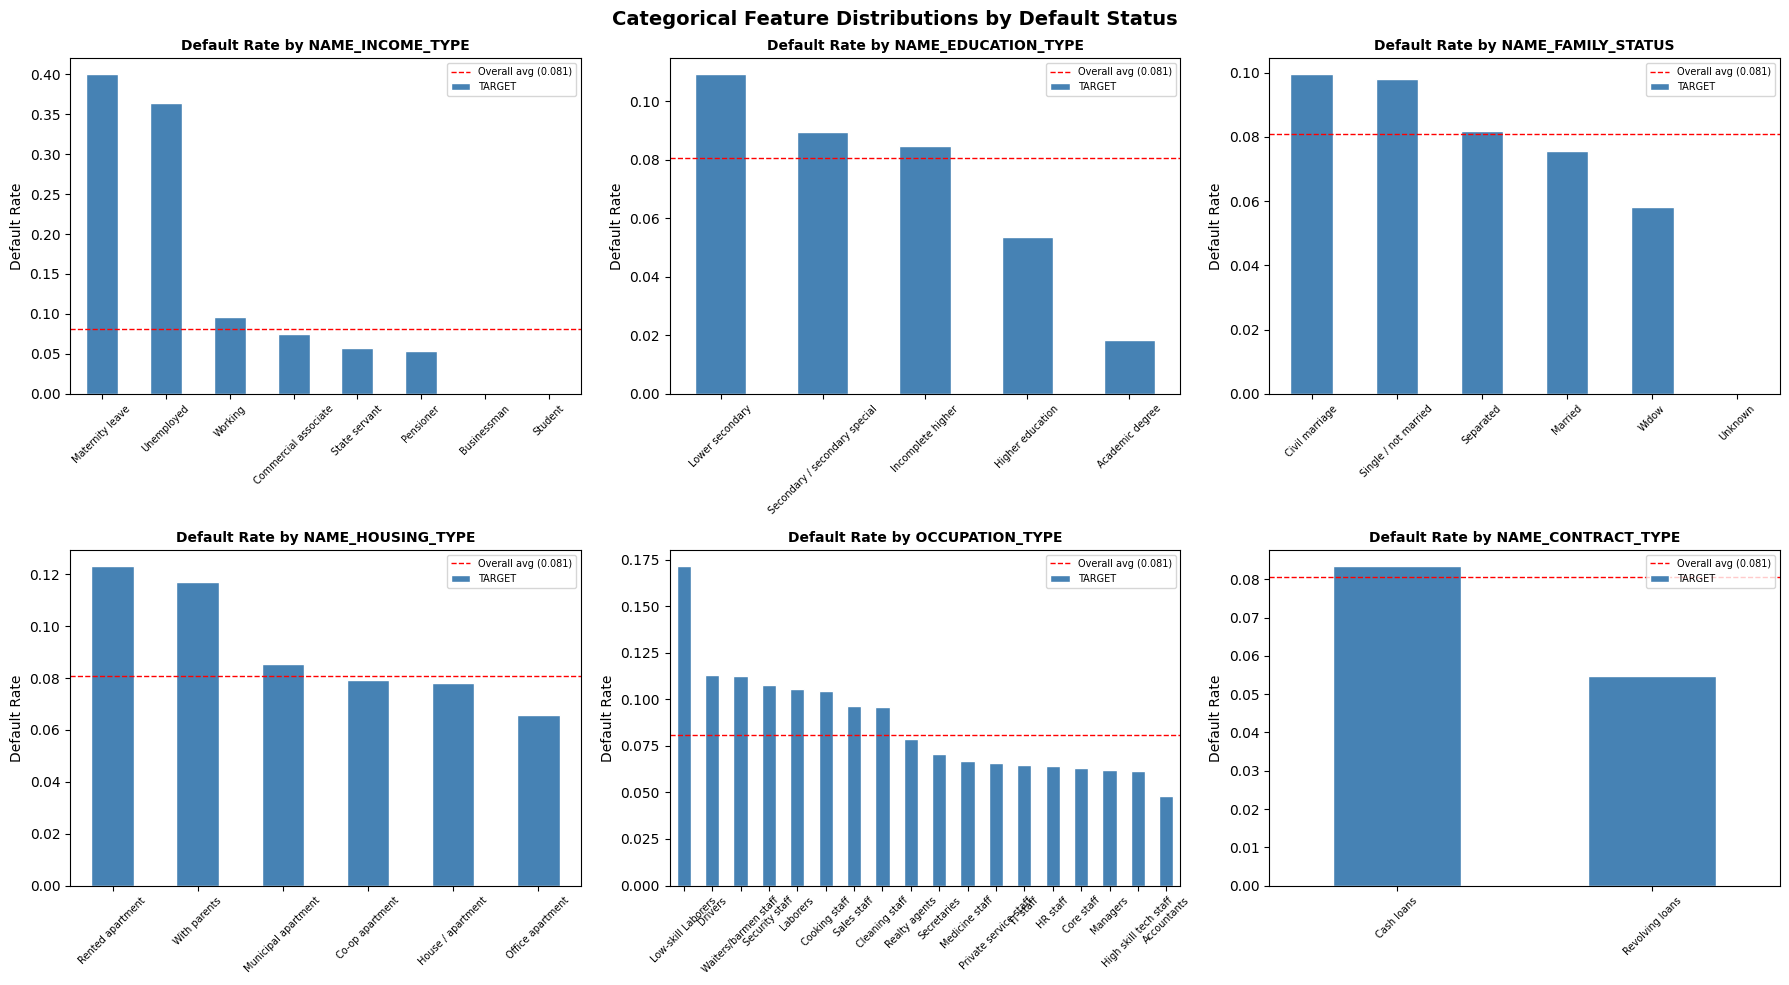

Categorical plots saved.


In [ ]:
# Class imbalance and categorical distributions

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Categorical Feature Distributions by Default Status', fontsize=14, fontweight='bold')

cat_features = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
                'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                'OCCUPATION_TYPE', 'NAME_CONTRACT_TYPE']
cat_features = [c for c in cat_features if c in df.columns]

for i, col in enumerate(cat_features[:6]):
    ax = axes[i // 3][i % 3]
    # Default rate per category
    rates = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Default Rate by {col}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Default Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.axhline(y=df['TARGET'].mean(), color='red', linestyle='--',
               linewidth=1, label=f'Overall avg ({df["TARGET"].mean():.3f})')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CIND820_Project/categorical_default_rates.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Categorical plots saved.")

In [ ]:
# YData Profiling report
# Generates a comprehensive automated HTML report

from ydata_profiling import ProfileReport

print("Generating YData Profiling report (this takes 5-10 minutes)...")
print("Do not close Colab while this runs.")

# Use a sample for speed — 50k rows captures the distribution well
df_sample = df.sample(n=50000, random_state=42)

profile = ProfileReport(
    df_sample,
    title="CIND820 — Home Credit EDA: YData Profiling Report",
    explorative=True,
    minimal=False,
    correlations={
        "pearson": {"calculate": True},
        "spearman": {"calculate": True},
        "kendall": {"calculate": False},
        "phi_k": {"calculate": False},
    },
    missing_diagrams={
        "bar": True,
        "matrix": True,
        "heatmap": True,
    },
    html={
        "style": {
            "primary_color": "#1f77b4",
        }
    }
)

# Save to Drive
ydata_path = '/content/drive/MyDrive/CIND820_Project/EDA_YData_Report.html'
profile.to_file(ydata_path)
print(f"YData report saved to: {ydata_path}")

Generating YData Profiling report (this takes 5-10 minutes)...
Do not close Colab while this runs.


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 70/70 [00:05<00:00, 12.86it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

YData report saved to: /content/drive/MyDrive/CIND820_Project/EDA_YData_Report.html


In [ ]:
# SweetViz TARGET comparison report
# Compares defaulters vs non-defaulters side by side across all features

import sweetviz as sv

print("Generating SweetViz comparison report...")

# Split into two groups for comparison
df_default   = df[df['TARGET'] == 1].sample(n=min(10000, (df['TARGET']==1).sum()), random_state=42)
df_repaid    = df[df['TARGET'] == 0].sample(n=min(10000, (df['TARGET']==0).sum()), random_state=42)

# Run comparison
sweet_report = sv.compare(
    [df_repaid,   "Repaid (No Default)"],
    [df_default,  "Defaulted"],
    target_feat='TARGET'
)

# Save to Drive
sv_path = '/content/drive/MyDrive/CIND820_Project/EDA_SweetViz_Report.html'
sweet_report.show_html(sv_path, open_browser=False)
print(f"SweetViz report saved to: {sv_path}")

Generating SweetViz comparison report...


                                             |          | [  0%]   00:00 -> (? left)

Report /content/drive/MyDrive/CIND820_Project/EDA_SweetViz_Report.html was generated.
SweetViz report saved to: /content/drive/MyDrive/CIND820_Project/EDA_SweetViz_Report.html


In [ ]:
# Copy both HTML reports to Colab local for download
import shutil

# Copy to Colab local directory so you can also download directly
shutil.copy(ydata_path, '/content/EDA_YData_Report.html')
shutil.copy(sv_path,    '/content/EDA_SweetViz_Report.html')

print("Both reports are ready:")
print("  /content/EDA_YData_Report.html")
print("  /content/EDA_SweetViz_Report.html")
print("\nTo download: click the folder icon on the left sidebar in Colab,")
print("navigate to /content/, right-click each file, and select Download.")
print("\nAlso saved to Google Drive at:")
print(f"  {ydata_path}")
print(f"  {sv_path}")

Both reports are ready:
  /content/EDA_YData_Report.html
  /content/EDA_SweetViz_Report.html

To download: click the folder icon on the left sidebar in Colab,
navigate to /content/, right-click each file, and select Download.

Also saved to Google Drive at:
  /content/drive/MyDrive/CIND820_Project/EDA_YData_Report.html
  /content/drive/MyDrive/CIND820_Project/EDA_SweetViz_Report.html


In [ ]:
# Final summary for your journal
print("=== EDA SUMMARY FOR YOUR PROJECT JOURNAL ===\n")

print(f"Dataset: Home Credit Default Risk")
print(f"Rows analyzed: {len(df):,} (full) | 50,000 (YData sample) | 10,000 per group (SweetViz)")
print(f"Features: {df.shape[1]} total after feature selection and engineering")
print(f"Class imbalance: {(df['TARGET']==0).sum():,} repaid ({(df['TARGET']==0).mean():.1%}) vs "
      f"{(df['TARGET']==1).sum():,} defaulted ({(df['TARGET']==1).mean():.1%})")

print(f"\nKey findings from EDA:")
print(f"  - {(df['INST_TOTAL_RECORDS'].isnull().sum()):,} applicants have no installment history (thin-file)")
print(f"  - {(df['BUR_TOTAL_LOANS'].isnull().sum()):,} applicants have no bureau records")
print(f"  - EXT_SOURCE_2 missing: {df['EXT_SOURCE_2'].isnull().sum():,} ({df['EXT_SOURCE_2'].isnull().mean():.1%})")
print(f"  - Max payment delay outlier: {df['INST_MAX_DAYS_PAST_DUE'].max():.0f} days")
print(f"  - Average debt-to-income ratio: {df['RATIO_DEBT_TO_INCOME'].mean():.2f}")

print(f"\nReports generated:")
print(f"  1. EDA_YData_Report.html — full automated profiling")
print(f"  2. EDA_SweetViz_Report.html — defaulter vs repaid comparison")
print(f"  3. univariate_analysis.png — distributions, boxplots, default overlays")
print(f"  4. correlation_heatmap.png — feature correlations")
print(f"  5. categorical_default_rates.png — default rate by category")
print(f"  6. feature_summary_stats.csv — skewness and missing ratio table")

=== EDA SUMMARY FOR YOUR PROJECT JOURNAL ===

Dataset: Home Credit Default Risk
Rows analyzed: 307,511 (full) | 50,000 (YData sample) | 10,000 per group (SweetViz)
Features: 70 total after feature selection and engineering
Class imbalance: 282,686 repaid (91.9%) vs 24,825 defaulted (8.1%)

Key findings from EDA:
  - 15,868 applicants have no installment history (thin-file)
  - 44,020 applicants have no bureau records
  - EXT_SOURCE_2 missing: 660 (0.2%)
  - Max payment delay outlier: 2884 days
  - Average debt-to-income ratio: 3.96

Reports generated:
  1. EDA_YData_Report.html — full automated profiling
  2. EDA_SweetViz_Report.html — defaulter vs repaid comparison
  3. univariate_analysis.png — distributions, boxplots, default overlays
  4. correlation_heatmap.png — feature correlations
  5. categorical_default_rates.png — default rate by category
  6. feature_summary_stats.csv — skewness and missing ratio table
